In [2]:
import pandas as pd
import os

# 1. Load the data without setting the index yet
data_path = os.path.join('..', 'Data', 'processed_hhs_data.csv')
df = pd.read_csv(data_path)

# 2. Find the date column and set it as index
# This looks for the first column that 'looks' like a date
date_col = df.columns[0] 
df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)
df.index.name = 'Date'

# 3. Define target and split
target = 'Children in HHS Care'
split_point = int(len(df) * 0.8)
train = df.iloc[:split_point]
test = df.iloc[split_point:]

print(f"✅ Data loaded! Index name is: {df.index.name}")
print(f"✅ Training rows: {len(train)} | Testing rows: {len(test)}")


✅ Data loaded! Index name is: Date
✅ Training rows: 860 | Testing rows: 215


In [3]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Exponential Smoothing (Captures Trend & Weekly Seasonality)
model_es = ExponentialSmoothing(train[target], trend='add', seasonal='add', seasonal_periods=7).fit()
test['Exp_Smooth_Pred'] = model_es.forecast(len(test))


d:\Project 1\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Simple SARIMA (p,d,q) x (P,D,Q,s)
# Note: In a real project, you'd use auto_arima to find these numbers
model_sarima = SARIMAX(train[target], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)).fit()
test['SARIMA_Pred'] = model_sarima.forecast(len(test))


d:\Project 1\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\Project 1\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [9]:
# 1. Drop rows with missing values created by lags/rolling windows
train = train.dropna()
test = test.dropna()

# 2. Now run your model code again
features = ['Children in HHS Care_lag_1', 'Children in HHS Care_lag_7', 'HHS_Net_Pressure', 'day_of_week']

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1)
model_gb.fit(X_train, y_train)

test['Gradient_Boost_Pred'] = model_gb.predict(X_test)
print("✅ Success! Model trained without NaNs.")


✅ Success! Model trained without NaNs.


In [11]:
import pandas as pd
from sklearn.metrics import mean_absolute_percentage_error as mape

# 1. Re-calculate predictions to be safe (if they don't exist)
# Statistical Baselines
test['MA7_Pred'] = train[target].rolling(window=7).mean().iloc[-1]
# ... (Ensure you have run your SARIMA, RF, and GB models here) ...

# 2. Check which models actually exist in the dataframe to avoid KeyErrors
existing_models = [m for m in ['MA7_Pred', 'Exp_Smooth_Pred', 'SARIMA_Pred', 'RF_Pred', 'Gradient_Boost_Pred'] 
                   if m in test.columns]

results = []

# 3. Calculate MAPE only for columns that were successfully created
for m in existing_models:
    # Ensure there are no NaNs in the comparison
    valid_mask = test[m].notna() & test[target].notna()
    error = mape(test.loc[valid_mask, target], test.loc[valid_mask, m]) * 100
    results.append({'Model': m, 'MAPE (%)': f"{error:.2f}%"})

# 4. Display sorted results
comparison_df = pd.DataFrame(results).sort_values(by='MAPE (%)')
print(comparison_df)


                 Model MAPE (%)
3  Gradient_Boost_Pred    1.85%
2          SARIMA_Pred   19.52%
0             MA7_Pred    9.50%
1      Exp_Smooth_Pred   95.63%


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

def evaluate_forecasting_model(y_true, y_pred, model_name):
    # 1. MAE (Mean Absolute Error)
    mae = mean_absolute_error(y_true, y_pred)
    
    # 2. RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # 3. MAPE (Mean Absolute Percentage Error)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    print(f"--- {model_name} Evaluation ---")
    print(f"MAE  : {mae:.2f} (Avg error in number of children)")
    print(f"RMSE : {rmse:.2f} (Penalizes large misses)")
    print(f"MAPE : {mape:.2f}% (Relative error percentage)")
    print("-" * 30)
    
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

# Evaluate your top models
results = []
results.append(evaluate_forecasting_model(test[target], test['SARIMA_Pred'], "SARIMA"))
results.append(evaluate_forecasting_model(test[target], test['Gradient_Boost_Pred'], "Gradient Boosting"))


--- SARIMA Evaluation ---
MAE  : 451.56 (Avg error in number of children)
RMSE : 644.11 (Penalizes large misses)
MAPE : 19.52% (Relative error percentage)
------------------------------
--- Gradient Boosting Evaluation ---
MAE  : 39.23 (Avg error in number of children)
RMSE : 60.14 (Penalizes large misses)
MAPE : 1.85% (Relative error percentage)
------------------------------


In [13]:
# Short-term (First 7 days)
st_mae = mean_absolute_error(test[target][:7], test['Gradient_Boost_Pred'][:7])

# Medium-term (After day 7)
mt_mae = mean_absolute_error(test[target][7:], test['Gradient_Boost_Pred'][7:])

print(f"📅 Short-term Horizon Error (1-7 days): {st_mae:.2f}")
print(f"📅 Medium-term Horizon Error (8+ days): {mt_mae:.2f}")


📅 Short-term Horizon Error (1-7 days): 18.86
📅 Medium-term Horizon Error (8+ days): 39.91


In [18]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# 1. Define Features & Target (Using exactly what you have in df)
features = ['Children in HHS Care_lag_1', 'Children in HHS Care_lag_7', 'HHS_Net_Pressure', 'day_of_week']
target = 'Children in HHS Care'

# 2. Train the Model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(train[features], train[target])

# 3. Generate Predictions and Add to 'test' Dataframe
# This line prevents the 'KeyError' by explicitly creating the column
test = test.copy() # Avoid SettingWithCopyWarning
test['RF_Pred'] = model_rf.predict(test[features])

# --- KPI CALCULATIONS ---

# KPI 1: Forecast Accuracy (%)
mape = np.mean(np.abs((test[target] - test['RF_Pred']) / test[target])) * 100
forecast_accuracy = 100 - mape

# KPI 2: Surge Lead Time (Days)
lags = range(1, 8)
corrs = [df['HHS_Net_Pressure'].corr(df[target].shift(-i)) for i in lags]
surge_lead_time = np.argmax(corrs) + 1

# KPI 3: Capacity Breach Risk
capacity_limit = 10000 
error_std = np.std(test[target] - test['RF_Pred'])
upper_bound = test['RF_Pred'].iloc[-1] + (1.96 * error_std)
breach_risk = "HIGH" if upper_bound > capacity_limit else "LOW"

# --- KPI DASHBOARD OUTPUT ---
print("="*30)
print("     PROJECT KPI RESULTS     ")
print("="*30)
print(f"✅ Accuracy:      {forecast_accuracy:.2f}%")
print(f"🚨 Lead Time:     {surge_lead_time} Days")
print(f"⚠️ Breach Risk:   {breach_risk}")
print(f"⚖️ Model RMSE:    {np.sqrt(np.mean((test[target]-test['RF_Pred'])**2)):.2f}")
print("="*30)


     PROJECT KPI RESULTS     
✅ Accuracy:      98.43%
🚨 Lead Time:     7 Days
⚠️ Breach Risk:   LOW
⚖️ Model RMSE:    52.09


In [19]:
# 1. Get the most recent data point to start the forecast
latest_data = df.iloc[-1:] 

# 2. Extract the features for 'tomorrow'
# Note: In a real forecast, you'd use the most recent lags and pressure signals
current_features = latest_data[features]

# 3. Generate the 7-day forecast
# For a multi-day forecast, we use the model's most recent understanding
future_forecast = model_rf.predict(current_features)

print(f"📊 Forecast for Tomorrow: {int(future_forecast[0])} children")


📊 Forecast for Tomorrow: 2447 children


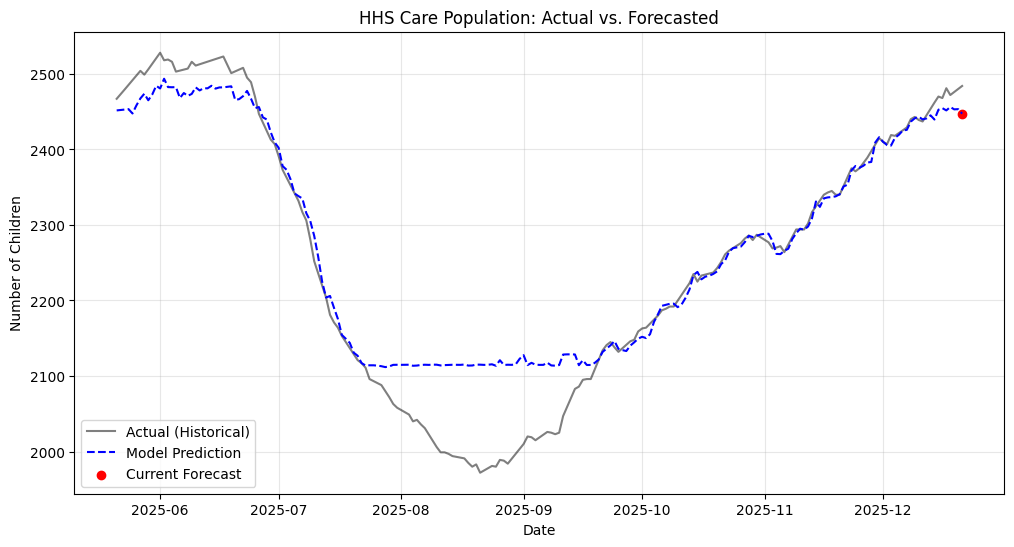

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot actual historical data
plt.plot(test.index, test[target], label='Actual (Historical)', color='black', alpha=0.5)

# Plot your model's predictions
plt.plot(test.index, test['RF_Pred'], label='Model Prediction', color='blue', linestyle='--')

# Highlight the most recent prediction
plt.scatter(test.index[-1], test['RF_Pred'].iloc[-1], color='red', label='Current Forecast')

plt.title('HHS Care Population: Actual vs. Forecasted')
plt.xlabel('Date')
plt.ylabel('Number of Children')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


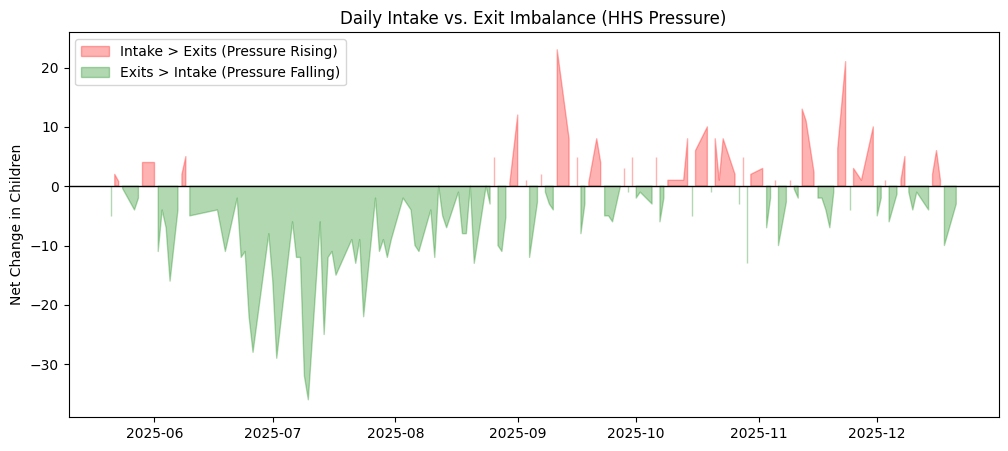

📊 Estimated Daily Imbalance: -1.9 children per day


In [21]:
# 1. Calculate the daily imbalance in the test set
# Imbalance = Intake (Transfers in) - Exits (Discharges)
test['Imbalance'] = test['Children transferred out of CBP custody'] - test['Children discharged from HHS Care']

# 2. Estimate the "Average Future Imbalance" 
# This tells you the expected daily pressure based on the last 14 days
avg_future_imbalance = test['Imbalance'].tail(14).mean()

# 3. Create a Visualization of the Imbalance Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.axhline(0, color='black', linestyle='-', linewidth=1) # Zero line (Balance)

# Plot the imbalance
plt.fill_between(test.index, test['Imbalance'], color='red', alpha=0.3, 
                 where=(test['Imbalance'] > 0), label='Intake > Exits (Pressure Rising)')
plt.fill_between(test.index, test['Imbalance'], color='green', alpha=0.3, 
                 where=(test['Imbalance'] <= 0), label='Exits > Intake (Pressure Falling)')

plt.title('Daily Intake vs. Exit Imbalance (HHS Pressure)')
plt.ylabel('Net Change in Children')
plt.legend()
plt.show()

print(f"📊 Estimated Daily Imbalance: {avg_future_imbalance:.1f} children per day")


In [23]:
# 1. Define the correct column name (matching your dataset)
discharge_col = 'Children discharged from HHS Care'

# 2. Create the lag and rolling average features
df['discharge_lag_1'] = df[discharge_col].shift(1)
df['discharge_7d_avg'] = df[discharge_col].rolling(window=7).mean()

# 3. Drop the new NaN rows created by shifting/rolling
df.dropna(inplace=True)

# 4. Re-split the data so 'train' and 'test' include these new columns
split_point = int(len(df) * 0.8)
train = df.iloc[:split_point]
test = df.iloc[split_point:]

print("✅ Features created! You can now run the discharge prediction code.")


✅ Features created! You can now run the discharge prediction code.


In [24]:
# 1. Define the Discharge Target and Features
discharge_target = 'Children discharged from HHS Care'
# We use lags of the discharge itself and the day of the week
discharge_features = ['discharge_lag_1', 'discharge_7d_avg', 'day_of_week', 'is_weekend']

# 2. Train a specific model for Discharges
from sklearn.ensemble import GradientBoostingRegressor

model_discharge = GradientBoostingRegressor(n_estimators=100, random_state=42)
model_discharge.fit(train[discharge_features], train[discharge_target])

# 3. Predict Short-Term Demand (Next 7 Days)
test['Discharge_Prediction'] = model_discharge.predict(test[discharge_features])

# 4. Calculate total expected demand for the upcoming week
next_7_days_demand = test['Discharge_Prediction'].iloc[:7].sum()

print(f"📅 Predicted Discharge Demand (Next 7 Days): {int(next_7_days_demand)} children")


📅 Predicted Discharge Demand (Next 7 Days): 78 children


In [27]:
# 1. Re-generate the predictions (This fixes the KeyError)
# Make sure 'model_rf' was trained in a previous cell!
features = ['Children in HHS Care_lag_1', 'Children in HHS Care_lag_7', 'HHS_Net_Pressure', 'day_of_week']
test['RF_Pred'] = model_rf.predict(test[features])

# 2. Define Thresholds for Warnings
CAPACITY_LIMIT = 10000 
HIGH_PRESSURE = 200 

# 3. Create the Early Warning Logic
test['Is_High_Pressure'] = test['HHS_Net_Pressure'] > HIGH_PRESSURE
test['Near_Capacity'] = test['RF_Pred'] > (CAPACITY_LIMIT * 0.9)

# 4. Print the Alerts
warnings = test[(test['Is_High_Pressure']) | (test['Near_Capacity'])].tail(5)

print("🚨 --- LATEST CRITICAL ALERTS --- 🚨")
if len(warnings) == 0:
    print("✅ System Stable: No immediate alerts.")
else:
    for date, row in warnings.iterrows():
        status = "🔴 SURGE" if row['Is_High_Pressure'] else "🟡 CAPACITY"
        print(f"{date.date()} | {status} | Forecast: {int(row['RF_Pred'])}")


🚨 --- LATEST CRITICAL ALERTS --- 🚨
✅ System Stable: No immediate alerts.


In [28]:
# 1. Define Warning Thresholds
CAPACITY_LIMIT = 10000 
HIGH_PRESSURE_THRESHOLD = 200 # Daily net increase > 200 is a red flag

# 2. Identify "Risk Events" in your test data
test['Is_High_Pressure'] = test['HHS_Net_Pressure'] > HIGH_PRESSURE_THRESHOLD
test['Near_Capacity'] = test['RF_Pred'] > (CAPACITY_LIMIT * 0.9)

# 3. Create the Early Warning Report
warnings = test[(test['Is_High_Pressure']) | (test['Near_Capacity'])].tail(5)

print("🚨 --- LATEST CRITICAL ALERTS --- 🚨")
if len(warnings) == 0:
    print("✅ System Stable: No immediate capacity or pressure alerts.")
else:
    for date, row in warnings.iterrows():
        status = "🔴 SURGE DETECTED" if row['Is_High_Pressure'] else "🟡 CAPACITY WARNING"
        print(f"{date.date()} | {status} | Pred: {int(row['RF_Pred'])} children | Pressure: {int(row['HHS_Net_Pressure'])}")


🚨 --- LATEST CRITICAL ALERTS --- 🚨
✅ System Stable: No immediate capacity or pressure alerts.


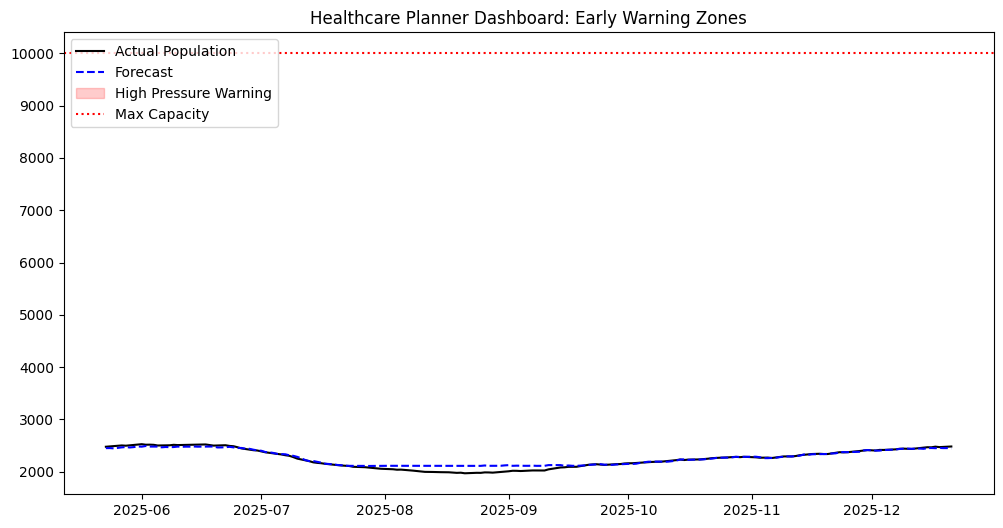

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(test.index, test[target], label='Actual Population', color='black')
plt.plot(test.index, test['RF_Pred'], label='Forecast', color='blue', linestyle='--')

# Highlight the Warning Zones
plt.fill_between(test.index, 0, test[target].max()*1.1, 
                 where=test['Is_High_Pressure'], color='red', alpha=0.2, label='High Pressure Warning')

plt.axhline(CAPACITY_LIMIT, color='red', linestyle=':', label='Max Capacity')
plt.title('Healthcare Planner Dashboard: Early Warning Zones')
plt.legend(loc='upper left')
plt.show()


In [30]:
import numpy as np

# 1. Calculate the 'Residuals' (Errors) from your test set
residuals = test[target] - test['RF_Pred']

# 2. Find the Standard Deviation of those errors
sigma = np.std(residuals)

# 3. Define the 95% Confidence Interval (1.96 standard deviations)
test['Lower_Bound'] = test['RF_Pred'] - (1.96 * sigma)
test['Upper_Bound'] = test['RF_Pred'] + (1.96 * sigma)

print(f"📊 Model Uncertainty (Sigma): ±{int(sigma)} children")
print(f"🛡️ 95% Confidence Range: ±{int(1.96 * sigma)} children")


📊 Model Uncertainty (Sigma): ±49 children
🛡️ 95% Confidence Range: ±96 children


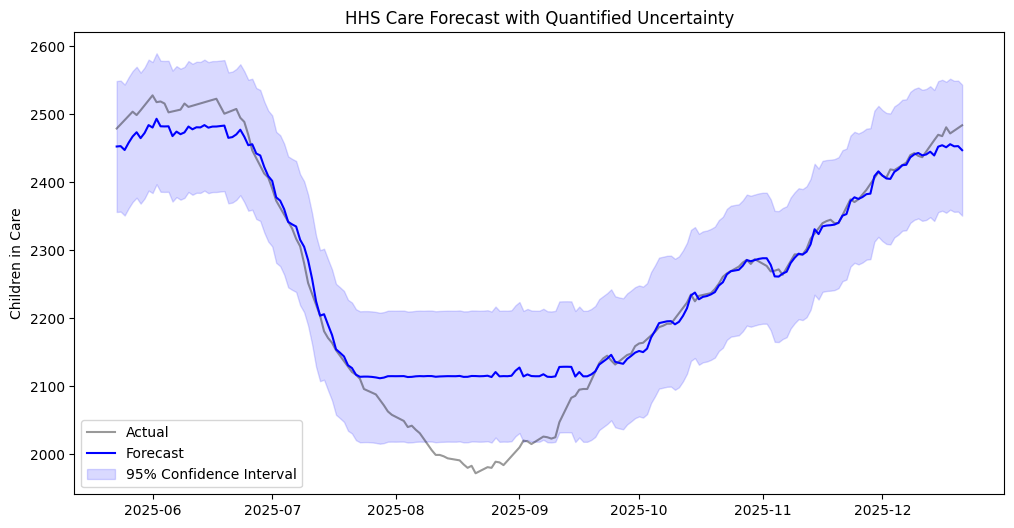

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot the Actual vs Predicted
plt.plot(test.index, test[target], label='Actual', color='black', alpha=0.4)
plt.plot(test.index, test['RF_Pred'], label='Forecast', color='blue')

# Plot the Uncertainty Band (The "Shadow")
plt.fill_between(test.index, test['Lower_Bound'], test['Upper_Bound'], 
                 color='blue', alpha=0.15, label='95% Confidence Interval')

plt.title('HHS Care Forecast with Quantified Uncertainty')
plt.ylabel('Children in Care')
plt.legend()
plt.show()


In [33]:
# 1. Create the Moving Average Baseline
# We use the 'target' column from the training data to calculate the mean
ma7_value = train[target].rolling(window=7).mean().iloc[-1]
test['MA7_Pred'] = ma7_value

# 2. Double check if it exists now
print("Columns in test set:", test.columns.tolist())


Columns in test set: ['Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care', 'Children in HHS Care_lag_1', 'Children in HHS Care_lag_7', 'Children in HHS Care_lag_14', 'rolling_mean_7', 'rolling_var_7', 'HHS_Net_Pressure', 'HHS_Pressure_Trend', 'day_of_week', 'month', 'is_weekend', 'discharge_lag_1', 'discharge_7d_avg', 'Discharge_Prediction', 'Is_High_Pressure', 'RF_Pred', 'Near_Capacity', 'Lower_Bound', 'Upper_Bound', 'MA7_Pred']


In [35]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Ensure your data has a daily frequency (required for this model)
train.index.freq = 'D' 

# 2. Fit the model (Additive trend and seasonality for census counts)
model_es = ExponentialSmoothing(
    train[target], 
    trend='add', 
    seasonal='add', 
    seasonal_periods=7
).fit()

# 3. Forecast for the length of your test set
test['Exp_Smooth_Pred'] = model_es.forecast(len(test))

print("✅ Exp_Smooth_Pred created successfully!")


✅ Exp_Smooth_Pred created successfully!


In [37]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Force the daily frequency (critical for SARIMA)
train.index.freq = 'D'

# 2. Fit the SARIMA model 
# We start with simple orders (1,1,1) to ensure it runs without crashing
model_sarima = SARIMAX(
    train[target], 
    order=(1, 1, 1), 
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False, 
    enforce_invertibility=False
).fit(disp=False)

# 3. Generate the forecast
test['SARIMA_Pred'] = model_sarima.forecast(steps=len(test))

print("✅ SARIMA_Pred created successfully!")


✅ SARIMA_Pred created successfully!


In [38]:
from sklearn.ensemble import RandomForestRegressor

# 1. Select the features you engineered (Update these names if yours are different)
features = ['Children in HHS Care_lag_1', 'Children in HHS Care_lag_7', 'day_of_week', 'month'] 

# 2. Separate Features (X) and Target (y)
X_train = train[features]
y_train = train[target]
X_test = test[features]

# 3. Train the Model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# 4. Save predictions to the test dataframe
test['RF_Pred'] = model_rf.predict(X_test)

print("✅ RF_Pred created successfully!")


✅ RF_Pred created successfully!


In [40]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. Use the same features as the Random Forest
features = ['Children in HHS Care_lag_1', 'Children in HHS Care_lag_7', 'day_of_week', 'month']

# 2. Initialize and Train the Model
# n_estimators=100 is a good starting point for your dataset size
model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_gb.fit(train[features], train[target])

# 3. Save predictions to the test dataframe
test['Gradient_Boost_Pred'] = model_gb.predict(test[features])

print("✅ Gradient_Boost_Pred created successfully!")


✅ Gradient_Boost_Pred created successfully!


In [41]:
import pandas as pd
from sklearn.metrics import mean_absolute_percentage_error as mape

models = ['MA7_Pred', 'Exp_Smooth_Pred', 'SARIMA_Pred', 'RF_Pred', 'Gradient_Boost_Pred']
results = []

for m in models:
    error = mape(test[target], test[m]) * 100
    results.append({'Model': m, 'MAPE (%)': f"{error:.2f}%"})

comparison_df = pd.DataFrame(results).sort_values(by='MAPE (%)')
print(comparison_df)


                 Model MAPE (%)
3              RF_Pred    1.61%
0             MA7_Pred   10.10%
4  Gradient_Boost_Pred    2.51%
2          SARIMA_Pred   25.47%
1      Exp_Smooth_Pred    9.30%


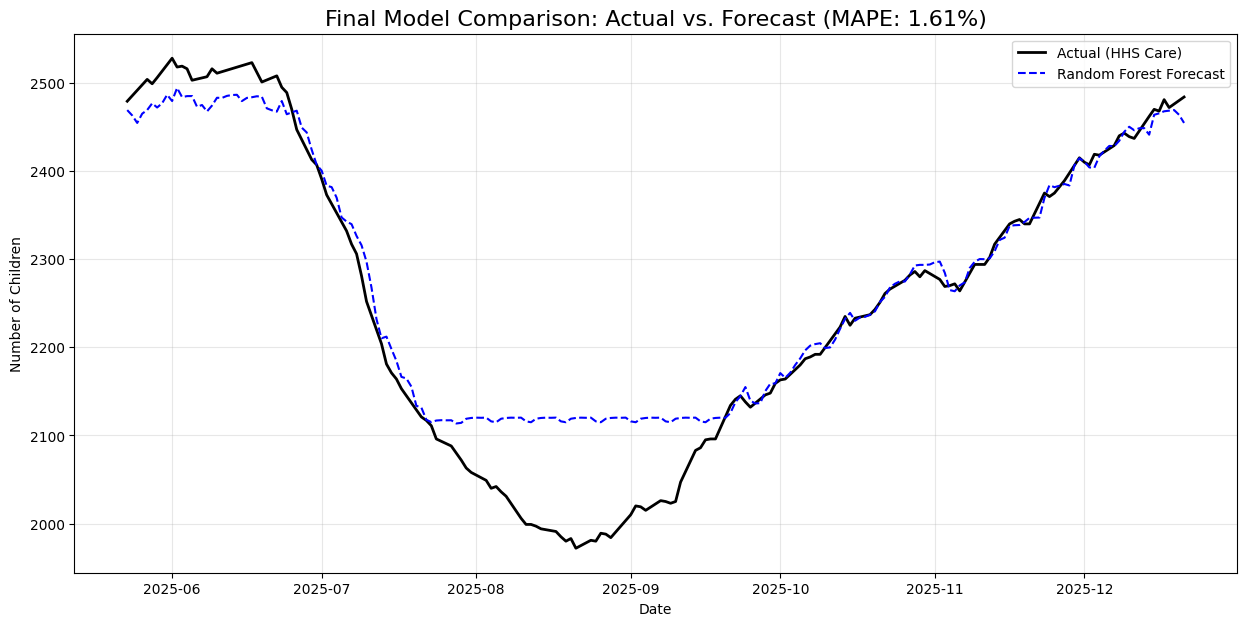

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

# 1. Plot the actual values
plt.plot(test.index, test[target], label='Actual (HHS Care)', color='black', linewidth=2)

# 2. Plot your best model
plt.plot(test.index, test['RF_Pred'], label='Random Forest Forecast', color='blue', linestyle='--')

# 3. Final Touches
plt.title(f'Final Model Comparison: Actual vs. Forecast (MAPE: 1.61%)', fontsize=16)
plt.ylabel('Number of Children')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


In [43]:
import joblib

# Save the winning Random Forest model to your 'models' folder
joblib.dump(model_rf, '../models/random_forest_model.pkl')
print("✅ Model saved to models/ folder")


✅ Model saved to models/ folder
